# VECM Prediction

VECM prediction uses the result of `statsmodels.tsa.vector_ar.vecm.VECM` parameter estimation analysis to forecast future values. When evaluating a model the data is split into training an prediction data. The training data set is used to evaluate the model and the prediction data set to evaluate the model performance. Several metrics are used to evaluate performance. First consider the bias which is defined by,

$
\begin{align}
B = \frac{1}{n}\sum_{i=1}^n \left(p_i - t_i\right)
\end{align}
\tag{1}
$
 
where $p_i$ is a prediction and $t_i$ a test sample. Next is the mean absolute error,

$
\begin{align}
E_{MAE} = \frac{1}{n}\sum_{i=1}^n | p_i - t_i |
\end{align}
\tag{2}
$

and finally the RMS error,

$
\begin{align}
E_{RMS} = \sqrt{\frac{1}{n}\sum_{i=1}^n  \left(p_i - t_i\right)^2}
\end{align}
\tag{2}
$

Of these measures $E_{MAE}$ is preferred since each term is weighted by error while $E_{RMS}$ wights larger errors more then small errors.


In [142]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf
from lib.plots import comparison, training, prediction

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [143]:
def plot_vecm_simulation(t, xt, λ, β, title):
    labels = [r"$x_1$", r"$x_2$", r"$x_3$"]   
    comparison(xt, t, labels =labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_training(xt, forecast_xt, err_upper_bound, err_lower_bound):
    nfcast, nplot  = forecast_xt.shape
    for i in range(nplot):
        ylabel = r"$X_{}$".format(i+1)
        training(forecast_xt[:,i], xt[i][-nfcast:], err_upper_bound[:,i], err_lower_bound[:,i], figsize=(10,4), ylabel=ylabel)

def plot_vecm_prediction(xt, forecast_xt, err_upper_bound, err_lower_bound):
    nfcast, nplot  = forecast_xt.shape
    for i in range(nplot):
        ylabel = r"$X_{}$".format(i+1)
        prediction(xt[i][:-nfcast], forecast_xt[:,i], err_upper_bound[:,i], err_lower_bound[:,i], figsize=(10,4), ylabel=ylabel)

## One Cointegrating Vector

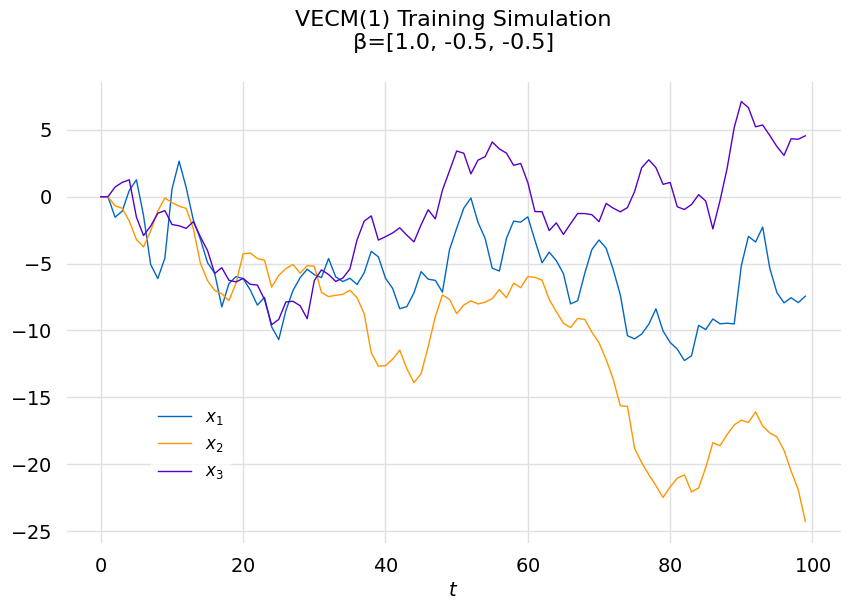

In [149]:
λ = numpy.matrix([-0.5, 0.0, 0.0]).T
β = numpy.matrix([1.0, -0.5, -0.5])
a = numpy.matrix([[0.5, 0.0, 0.0],
                  [0.0, 0.5, 0.0],
                  [0.0, 0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0, 0.0],
                  [0.0, 1.0, 0.0],
                  [0.0, 0.0, 1.0]])

title = f"VECM(1) Training Simulation\nβ=[{β[0,0]}, {β[0,1]}, {β[0,2]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω, npts=110)
plot_vecm_simulation(t[:-10], xt[:,:-10], λ, β, title)

In [150]:
result, result_model = vecm.compute_estimate(xt[:,:-10], maxlags=1, rank=1)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.2053,0.102,-2.008,0.045,-0.406,-0.005
L1.y1,0.5128,0.066,7.726,0.000,0.383,0.643
L1.y2,-0.0523,0.099,-0.526,0.599,-0.247,0.142
L1.y3,0.1716,0.099,1.734,0.083,-0.022,0.366
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.1252,0.101,-1.240,0.215,-0.323,0.073
L1.y1,0.0298,0.066,0.455,0.649,-0.099,0.158
L1.y2,0.4789,0.098,4.881,0.000,0.287,0.671
L1.y3,-0.0296,0.098,-0.303,0.762,-0.221,0.162
,coef,std err,z,P>|z|,[0.025,0.975]


In [151]:
forecast_xt, err_upper_bound, err_lower_bound = vecm.compute_prediction(result, 10)

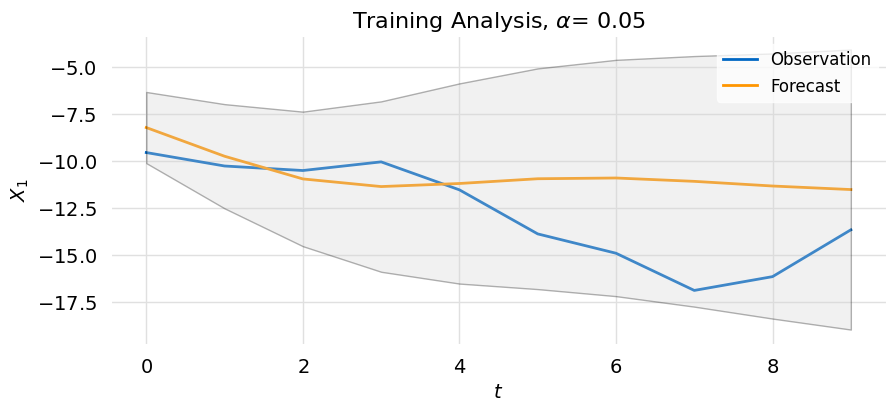

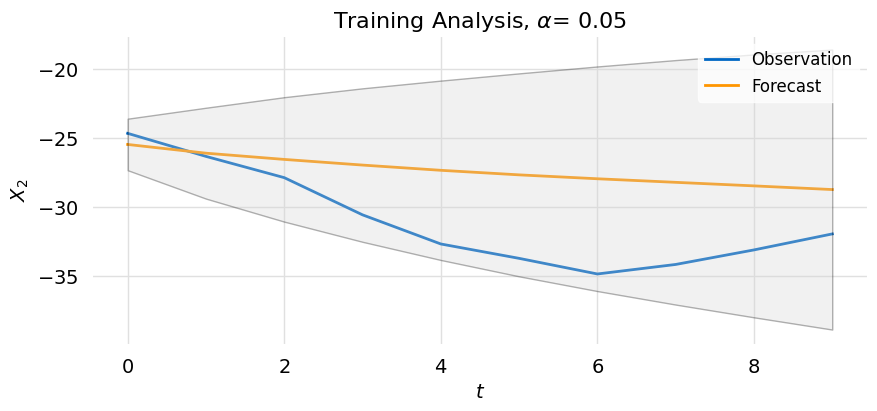

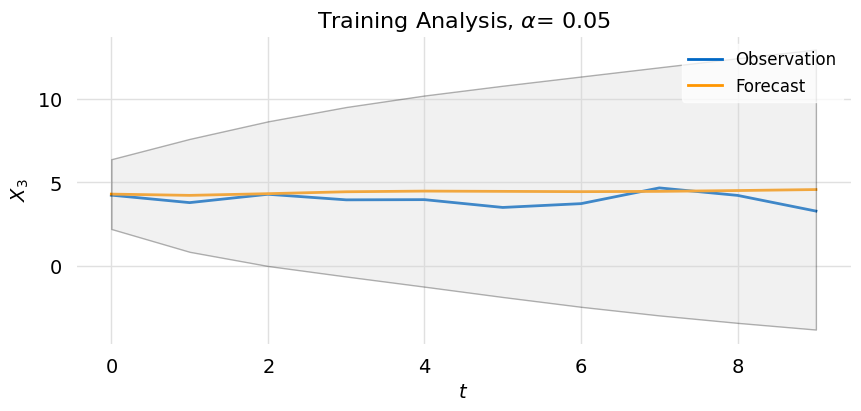

In [152]:
plot_vecm_training(xt, forecast_xt, err_upper_bound, err_lower_bound)

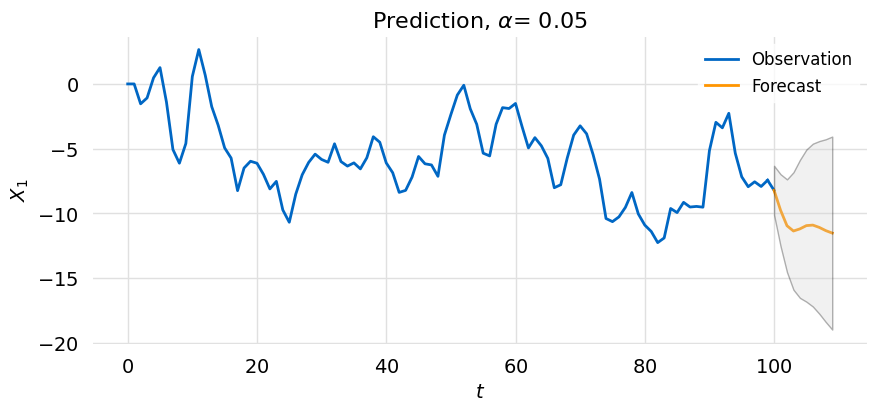

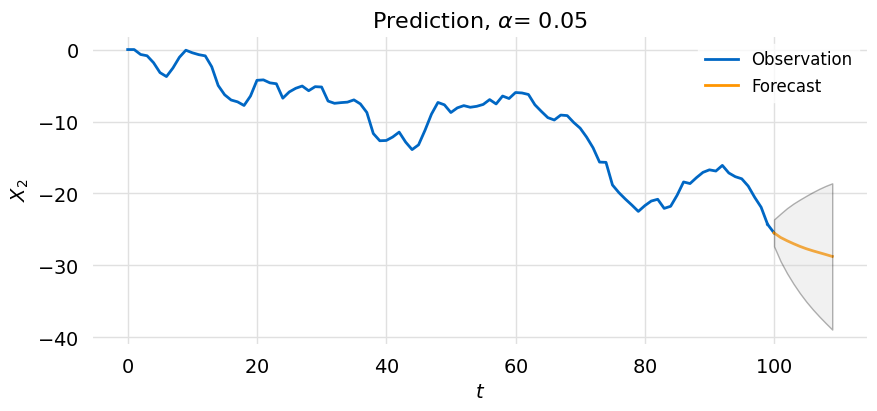

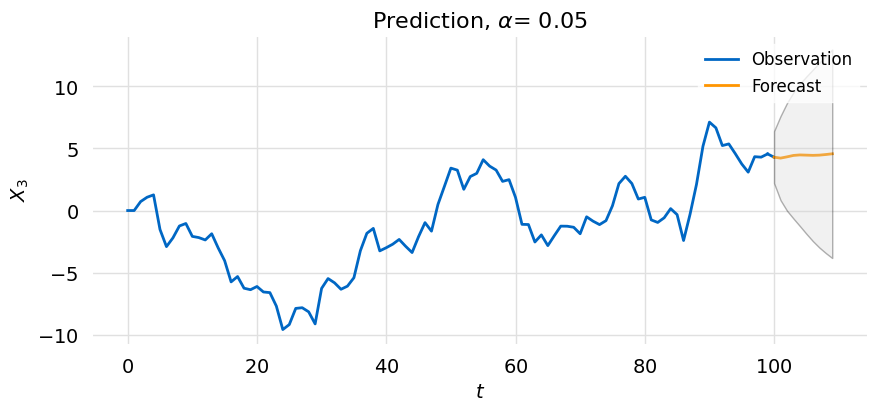

In [153]:
plot_vecm_prediction(xt, forecast_xt, err_upper_bound, err_lower_bound)